In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def diff1(t,p):
  return (0.8**2) * p * (1 - 2*p/10) * (1 - p/10)

def diff2(t,p):
  return 0.8**3 * p * (1 - p/10)* (1 - 6*p/10*(1 - p/10))

In [3]:
def function(t,p):
  return 0.8*p*(1 - p / 10)

def exact(t):
  return 10 / (1 + ((10 - 1) /1)*np.exp(-0.8*t))

In [4]:
class taylorAprox:
  def __init__(self, y0, ti,tf,h,function,order):
    self.y0 = y0
    self.ti = ti
    self.tf = tf
    self.h = h
    self.function = function
    self.order = order

  def fit(self):
    N = int(np.ceil((self.tf - self.ti) / self.h))
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0] = self.y0
    t[0] = self.ti
    if self.order == 1:
      for i in range(N):
        y[i + 1] = y[i] + self.function(t[i],y[i])*self.h
        t[i + 1] = t[i] + self.h
    elif self.order == 2:
      for i in range(N):
        y[i + 1] = y[i] + self.function(t[i],y[i])*self.h + (diff1(t[i],y[i])*self.h**2)/2
        t[i + 1] = t[i] + self.h
    elif self.order == 3:
      for i in range(N):
        y[i + 1] = y[i] + self.function(t[i],y[i])*self.h + (diff1(t[i],y[i])*self.h**2)/2 + (diff2(t[i],y[i])*self.h**3) / 6
        t[i + 1] = t[i] + self.h
    else:
      print("Sorryyyyyy")
    return t,y



In [5]:
aprox1 = taylorAprox(1,0,10,2,function,order = 1)
aprox2 = taylorAprox(1,0,10,2,function,order = 2)
aprox3 = taylorAprox(1,0,10,2,function,order = 3)

t,y1 = aprox1.fit()
t,y2 = aprox2.fit()
t,y3 = aprox3.fit()

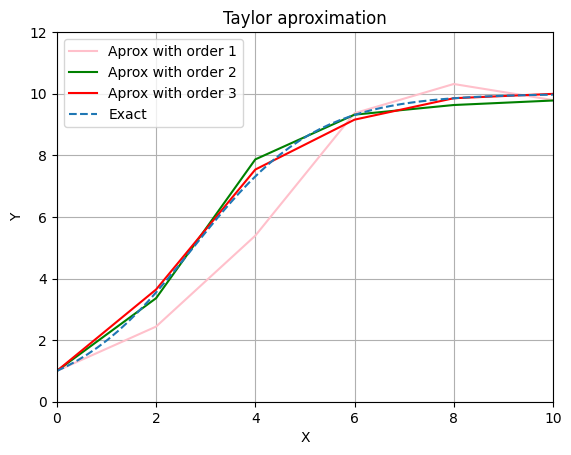

In [7]:
t1 = np.linspace(0,10)
plt.plot(t,y1,label = f"Aprox with order {1}",color = 'pink')
plt.plot(t,y2,label = f"Aprox with order {2}", color = 'green')
plt.plot(t,y3,label = f"Aprox with order {3}", color = 'red')
plt.plot(t1,exact(t1), label = "Exact", linestyle = '--')
plt.legend()
plt.title("Taylor aproximation")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis([0,10,0,12])
plt.savefig("Taylor aproximation")
plt.grid()
plt.show()